### The dataset fraud.csv is relevant to this question.
a. Report the imbalance ratio of the dataset. [1 mark]

b.Visualize the dataset in 2D and comment about it. [3 marks]

c.Train a baseline logistic regression or random forest model without any class rebalancing. Report and interpret: [2 marks]

i.Accuracy
ii.Precision, Recall, F1-score (especially for the minority class)

d.To handle the imbalance, apply all of the following techniques (stating you reasons, choose your own rebalancing ratio): [8 marks]
i.Random under-sampling of majority class.
ii.Random over-sampling of minority class.
iii.SMOTE
iv.Tomek links

e.Visualize the dataset before and after your rebalancing technique. [2 marks]

f.Train a model on your rebalanced datasets for each technique. Evaluate this model on the original dataset and compare its performance to the baseline model that you trained in 3(c), above. 
What do you think, did your rebalancing step help train a better model? Justify your answer. [4 marks]

In [71]:
# Importing necessary libraries
# General Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# ML library
from sklearn import model_selection
from sklearn import linear_model
from sklearn import metrics
from sklearn import linear_model

# Data Balancing Library
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

In [72]:
## Initialize Global variables and algorithm parameters
random_state = 42
max_pc_bars = 50 # how many PCs to show as bars (for readability)
pca_for_tsne_n_components = 50 # reduce with PCA before t-SNE (speed & noise reduction)
tsne_perplexity = 30
tsne_n_iter = 500

classification_algorithms = {
    'Logistic-Regression': LogisticRegression(multi_class='auto',random_state=42, max_iter=2000),
    'RandomForest': RandomForestClassifier(random_state=42),
}

### a. Report the imbalance ratio of the dataset. [1 mark]

N Examples: 5000
N Inputs: 13
N Classes: 2
Classes: [0 1]


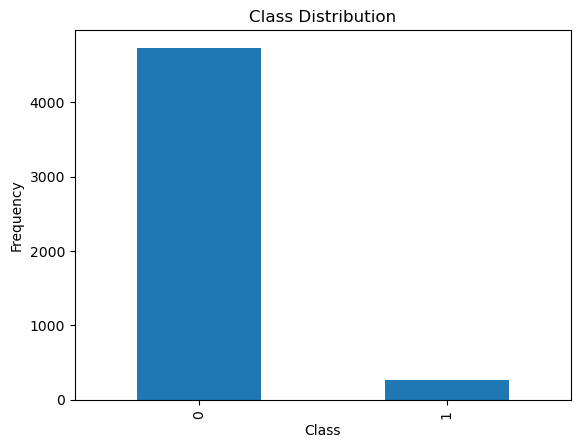

Percentage of class 0: 94.62%
Percentage of class 1: 5.38%
Ratio of class 0 to class 1: 17.59
Counts of each class: Counter({0: 4731, 1: 269})


In [73]:
# Load csv
df = pd.read_csv('fraud.csv')

X = df.drop('Class', axis=1)
y = df['Class']

# gather details
n_rows = X.shape[0]
n_cols = X.shape[1]
classes = np.unique(y)
n_classes = len(classes)

# summarize
print('N Examples: %d' % n_rows)
print('N Inputs: %d' % n_cols)
print('N Classes: %d' % n_classes)
print('Classes: %s' % classes)
class0_count, class1_count = y.value_counts()

df['Class'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()  
# Print the percentage of each class
print('Percentage of class 0: %.2f%%' % (class0_count /
        (class0_count + class1_count) * 100))
print('Percentage of class 1: %.2f%%' % (class1_count /
        (class0_count + class1_count) * 100))
# Print the ratio of class 0 to class 1
print('Ratio of class 0 to class 1: %.2f' % (class0_count / class1_count))
# Print the counts of each class
print('Counts of each class: %s' % Counter(y))



### b. Visualize the dataset in 2D and comment about it. [3 marks]

In [74]:

def train_and_evaluate_with_pca_and_tsne(X):
    # Ensure X only contains the features you want to analyze with PCA
    # Step 1: Standardize the data
    # PCA is affected by scale, so standardization (mean=0, variance=1) is crucial.
    scaler = StandardScaler(with_mean=True, with_std=True)
    X_scaled = scaler.fit_transform(X)

    # Step 2: Perform PCA
    # We use all components initially to analyze total variance contribution
    pca = PCA(n_components=None, svd_solver='full', random_state=random_state)
    X_pca = pca.fit_transform(X_scaled)
    
    # Step 3: Perform t-SNE
    # t-SNE is computationally intensive; we can reduce dimensionality first with PCA
    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    X_tsne = tsne.fit_transform(X_scaled)
    tsne_note = "(t-SNE on full dataset)"

    # Step 3: Extract explained variance ratios
    # The explained_variance_ratio_ attribute provides the percentage of variance 
    # explained by each individual principal component.
    explained_variance = pca.explained_variance_ratio_
    cum_var = np.cumsum(explained_variance)
    for i in range(min(10, len(explained_variance))):
        print(f"PC{i+1:3d}: explained variance ratio = {explained_variance[i]:.4f}, cumulative = {cum_var[i]:.4f}")
    # --- Plotting the Contributions (Bar Chart) ---
    for pct in [0.90, 0.95, 0.99]:
        k = np.searchsorted(cum_var, pct) + 1
        print(f"PCs needed to explain {int(pct*100)}% variance: {k}")
        
    # Create labels for the X-axis (PC1, PC2, PC3, ...)
    pc_labels = [f"PC{i+1}" for i in range(len(explained_variance))]


    plt.figure(figsize=(10,5))
    ax = plt.gca()
    ax.bar(np.arange(1, len(explained_variance)+1), explained_variance)
    ax.set_xlabel("Principal Component (k)")
    ax.set_ylabel("Explained Variance Ratio (bar)")
    ax2 = ax.twinx()
    ax2.plot(np.arange(1, len(cum_var)+1), cum_var, marker='o', linewidth=1, c='red')
    ax2.set_ylabel("Cumulative Explained Variance")
    ax2.set_ylim(0, 1.02)
    plt.title("Explained Variance + Cumulative (bars + curve)")
    plt.tight_layout()
    plt.show()
    

    # Plot PCA and t-SNE
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # PCA plot
    for cls in np.unique(y):
        mask = (y == cls)
        axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                        s=12, alpha=0.6, label=f'class {cls}')
    axes[0].set_title('PCA (2D)')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].legend()

    # t-SNE plot
    for cls in np.unique(y):
        mask = (y == cls)
        axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                        s=12, alpha=0.6, label=f'class {cls}')
    axes[1].set_title(f't-SNE (2D) {tsne_note}')
    axes[1].set_xlabel('t-SNE 1')
    axes[1].set_ylabel('t-SNE 2')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return X_scaled

PC  1: explained variance ratio = 0.2373, cumulative = 0.2373
PC  2: explained variance ratio = 0.1125, cumulative = 0.3497
PC  3: explained variance ratio = 0.0810, cumulative = 0.4308
PC  4: explained variance ratio = 0.0804, cumulative = 0.5112
PC  5: explained variance ratio = 0.0781, cumulative = 0.5893
PC  6: explained variance ratio = 0.0775, cumulative = 0.6667
PC  7: explained variance ratio = 0.0763, cumulative = 0.7430
PC  8: explained variance ratio = 0.0758, cumulative = 0.8188
PC  9: explained variance ratio = 0.0738, cumulative = 0.8926
PC 10: explained variance ratio = 0.0720, cumulative = 0.9646
PCs needed to explain 90% variance: 10
PCs needed to explain 95% variance: 10
PCs needed to explain 99% variance: 11


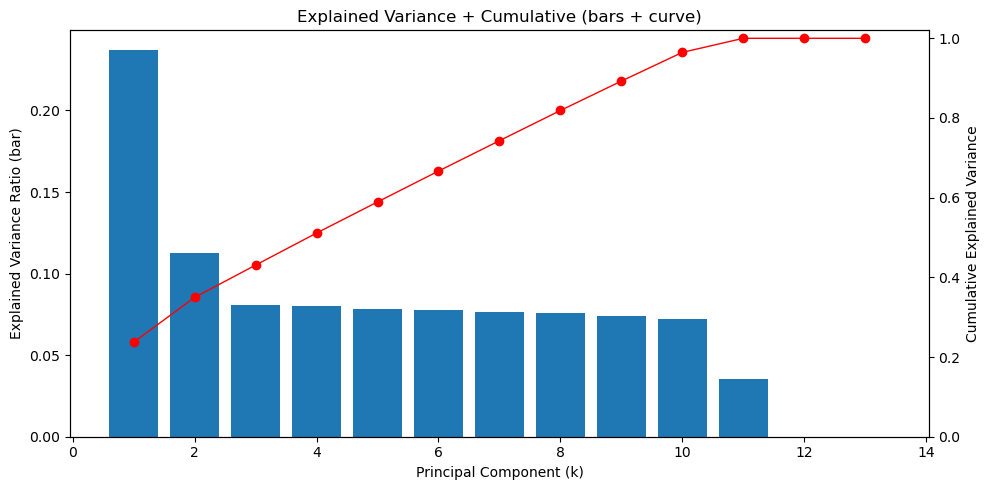

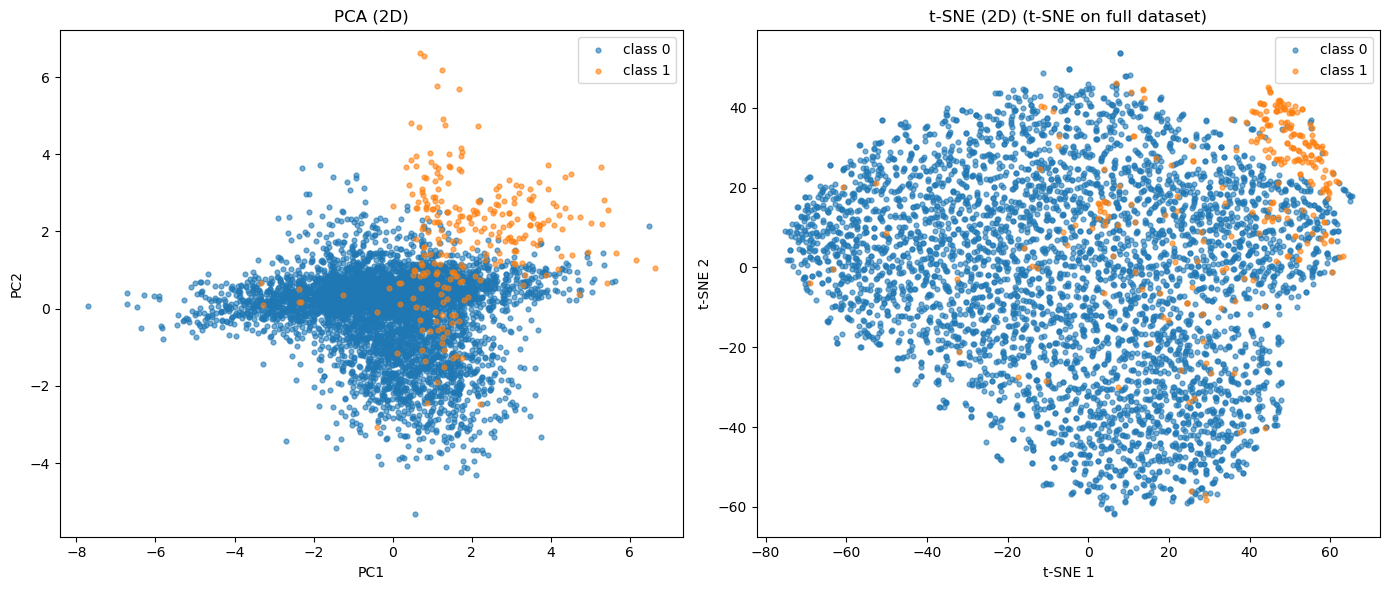

array([[-1.09299233,  0.47414418, -0.29648696, ...,  2.09287359,
        -0.85782975, -0.49833546],
       [ 0.18477171,  2.34430195, -3.10417261, ..., -0.12422879,
         1.97543439,  0.29846272],
       [ 0.81076658,  0.17474877, -0.58735294, ..., -1.23509351,
        -0.84061044, -0.14301558],
       ...,
       [ 1.06448369, -0.63261826, -0.05812033, ...,  1.13385075,
         0.97178287, -0.68098951],
       [-0.57186123, -1.24036413,  1.09785552, ..., -0.17653611,
        -1.65624215, -1.28737741],
       [-0.2641907 ,  0.63089162, -0.27957309, ..., -0.23248261,
        -1.97221735,  0.61468669]], shape=(5000, 13))

In [26]:
train_and_evaluate_with_pca_and_tsne(X)

In [75]:
def fit_to_logistic_regression(algorithm, x_train, x_test, y_train, y_test, data):
    algorithm.fit(x_train, y_train)
    # Make predictions on the test set
    y_test_pred = algorithm.predict(x_test)
    y_test_pred_prob = algorithm.predict_proba(x_test)
    
    y_train_pred = algorithm.predict(x_train)
    y_train_pred_prob = algorithm.predict_proba(x_train)
    
    accuracy_train = accuracy_score(y_train, y_train_pred)
    precision_train = precision_score(y_train, y_train_pred, average='micro')
    recall_train = recall_score(y_train, y_train_pred, average='micro')
    f1score_train = f1_score(y_train, y_train_pred, average='micro')
    data['train_or_test_data'].append('train')
    data['accuracy'].append(accuracy_train)
    data['precision'].append(precision_train)
    data['recall'].append(recall_train)
    data['F1'].append(f1score_train)
    print(f" -->> TRAIN -->> Accuracy: {accuracy_train:.4f} |Precision: {precision_train:.4f} |Recall: {recall_train:.4f} |F1_score: {f1score_train:.4f}")
     # Evaluate the model
    accuracy_test = accuracy_score(y_test, y_test_pred)
    precision_test = precision_score(y_test, y_test_pred, average='micro')
    recall_test = recall_score(y_test, y_test_pred, average='micro')
    f1score_test = f1_score(y_test, y_test_pred, average='micro')
    data['train_or_test_data'].append('test')
    data['accuracy'].append(accuracy_test)
    data['precision'].append(precision_test)
    data['recall'].append(recall_test)
    data['F1'].append(f1score_test)
    print(f" -->> TEST -->> Accuracy: {accuracy_test:.4f} |Precision: {precision_test:.4f} |Recall: {recall_test:.4f} |F1_score: {f1score_test:.4f}")
    return data

In [76]:
""" 
c. Train a baseline logistic regression or random forest model without any class rebalancing. Report and interpret: [2 marks]
i.Accuracy
ii.Precision, Recall, F1-score (especially for the minority class)
"""
#split data
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
data = {
            'algorithm_name': [],
            'train_or_test_data': [],
            'accuracy': [],
            'precision': [],
            'recall': [],
            'F1': [],
            'AUC': [],
        }

for algorithm_name, algorithm in classification_algorithms.items():
    print(f"Algorithm: {algorithm_name}")
    fit_to_logistic_regression(algorithm, X_train, X_test, y_train, y_test, data)

Algorithm: Logistic-Regression
 -->> TRAIN -->> Accuracy: 0.9725 |Precision: 0.9725 |Recall: 0.9725 |F1_score: 0.9725
 -->> TEST -->> Accuracy: 0.9690 |Precision: 0.9690 |Recall: 0.9690 |F1_score: 0.9690
Algorithm: RandomForest


c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


 -->> TRAIN -->> Accuracy: 1.0000 |Precision: 1.0000 |Recall: 1.0000 |F1_score: 1.0000
 -->> TEST -->> Accuracy: 0.9740 |Precision: 0.9740 |Recall: 0.9740 |F1_score: 0.9740


In [77]:
def trainAndTest(X, y, strategy, use_strag):
  np.random.seed(5)
  # split into train/test sets with same class ratio
  trainX, testX, trainy, testy = model_selection.train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

  # #Apply sampling technique if any
  if use_strag:
    trainX, trainy = strategy.fit_resample(trainX, trainy)
  # # define model
  # model = linear_model.LogisticRegression(solver='liblinear')
  # # fit model
  # model.fit(trainX, trainy)
  # # predict on test set
  # yhat = model.predict(testX)
  # # evaluate predictions
  # acc = metrics.accuracy_score(testy, yhat)
  # prec = metrics.precision_score(testy, yhat)
  # recall = metrics.recall_score(testy, yhat)
  # f1_score = metrics.f1_score(testy, yhat)

  return trainX, testX, trainy, testy

In [78]:
def technique(X,y):

  # summarize class distribution
  print("Original :",Counter(y))

  ### TomekLinks
  undersample = TomekLinks()

  ### SMOTE
  oversample = SMOTE(sampling_strategy=0.5)

  ### SMOTEENN
  sample = SMOTEENN(sampling_strategy=0.5)

  ### Evaluation
  X, testX, y, testy = trainAndTest(X, y,False,False)
  X_over, X_overtestX, y_over, y_overtesty = trainAndTest(X, y, oversample, True )
  X_under, X_undertestX, y_under, y_undertesty = trainAndTest(X, y, undersample, True)
  X_uo, X_uotestX, y_uo, y_uotesty = trainAndTest(X, y, sample, True)

  # df_result = pd.DataFrame({
  #   'Accuracy': [acc_orig, acc_over, acc_under, acc_both],
  #   'Precision': [prec_orig, prec_over, prec_under, prec_both],
  #   'Recall': [recall_orig, recall_over, recall_under, recall_both],
  #   'F1_score': [f1_orig, f1_over, f1_under, f1_both]
  # })

  # df_result.index = ['Original data', 'SMOTE', 'TomekLinks', 'SMOTEENN']

  ### Plotting

  fig, ax = plt.subplots(2, 2,figsize=(10,10))

  ax[0, 0].bar(["1","2"], y.value_counts())
  ax[0, 0].set_title("Original Dataset")
  ax[0, 1].bar(["1","2"], y_over.value_counts())
  ax[0, 1].set_title("SMOTE")
  ax[1, 0].bar(["1","2"], y_under.value_counts())
  ax[1, 0].set_title("TomekLinks")
  ax[1, 1].bar(["1","2"], y_uo.value_counts())
  ax[1, 1].set_title("SMOTEENN")
  plt.show()


  pd.plotting.scatter_matrix(X, c = y, figsize=(10,10))
  plt.suptitle("Original Dataset")
  pd.plotting.scatter_matrix(X_over, c = y_over, figsize=(10,10))
  plt.suptitle("After Oversampling")
  plt.show()
  pd.plotting.scatter_matrix(X_under, c = y_under, figsize=(10,10))
  plt.suptitle("After UnderSampling")
  plt.show()
  pd.plotting.scatter_matrix(X_uo, c = y_uo, figsize=(10,10))
  plt.suptitle("After Over and Under sampling")
  plt.show()

Original : Counter({0: 4731, 1: 269})


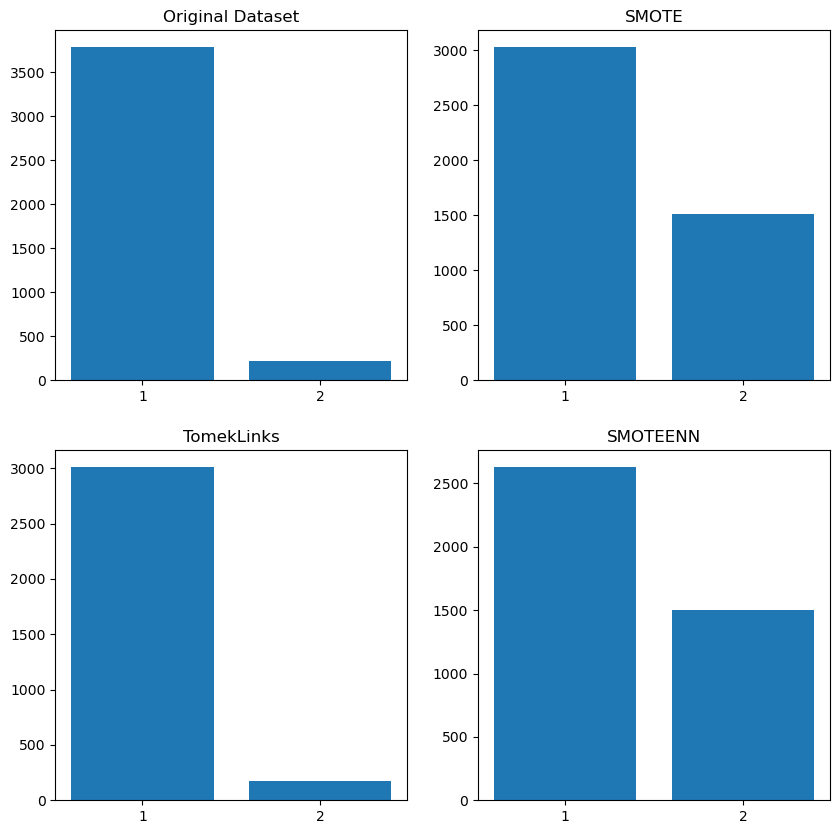

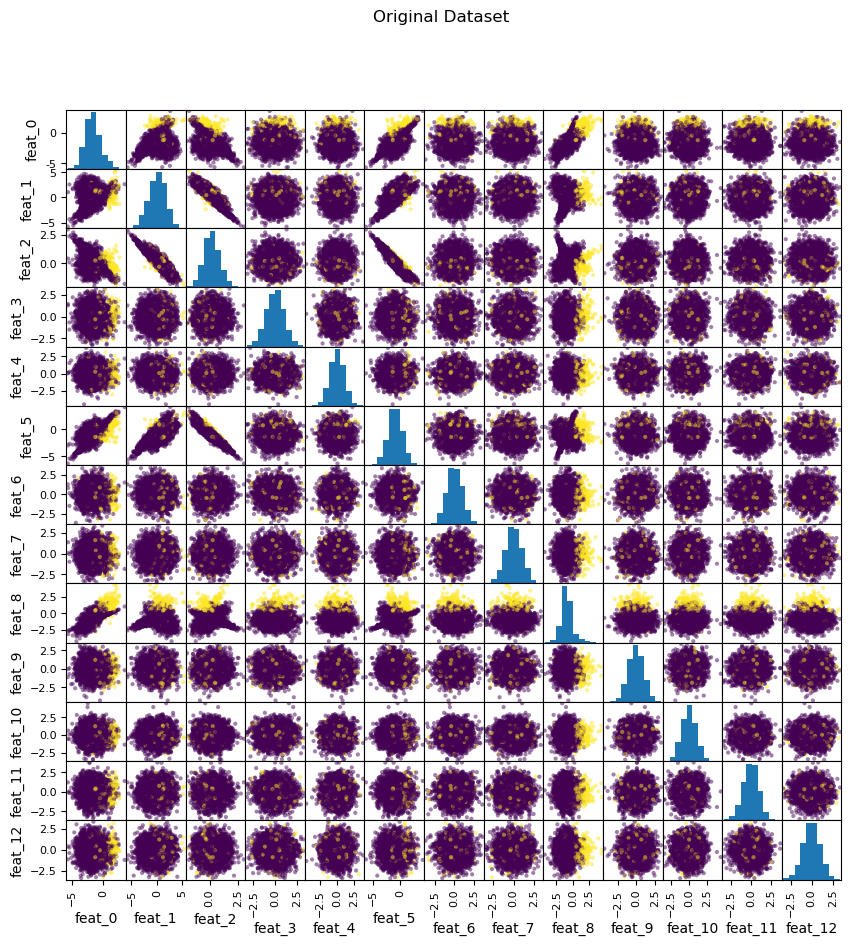

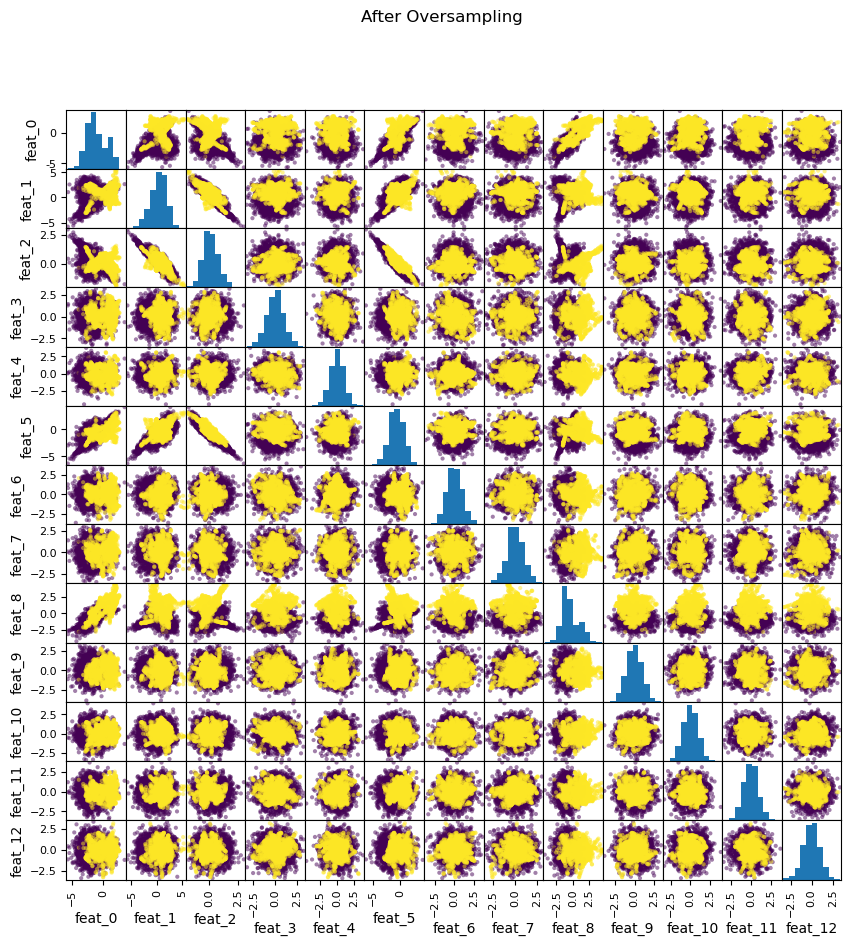

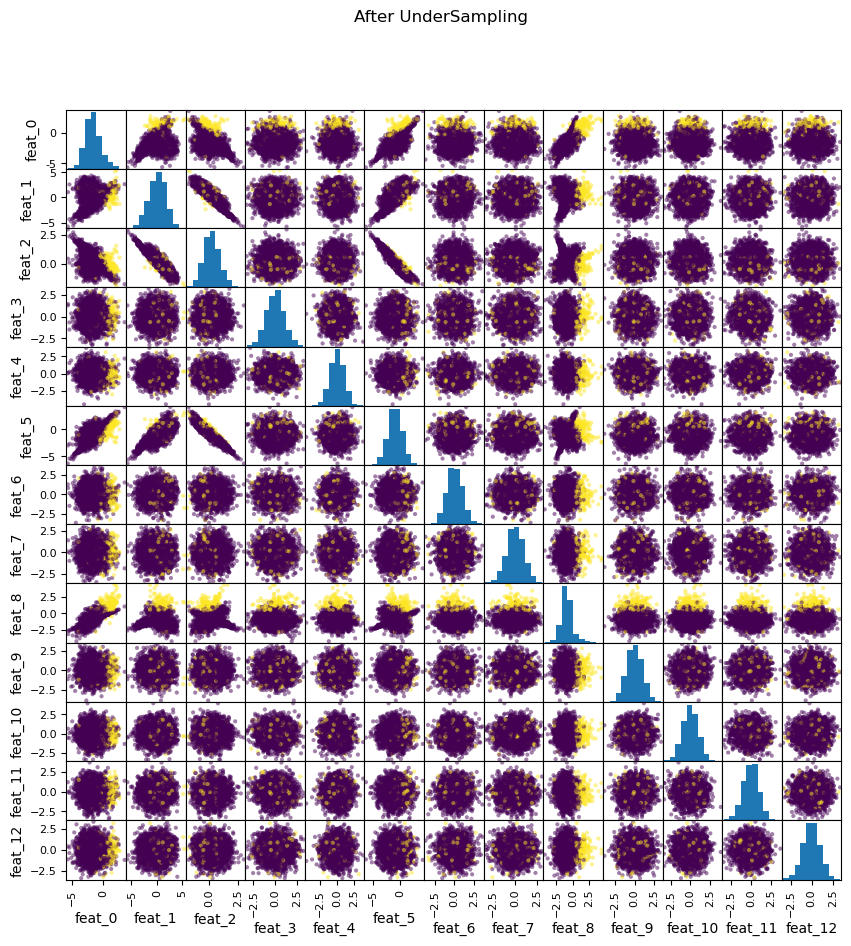

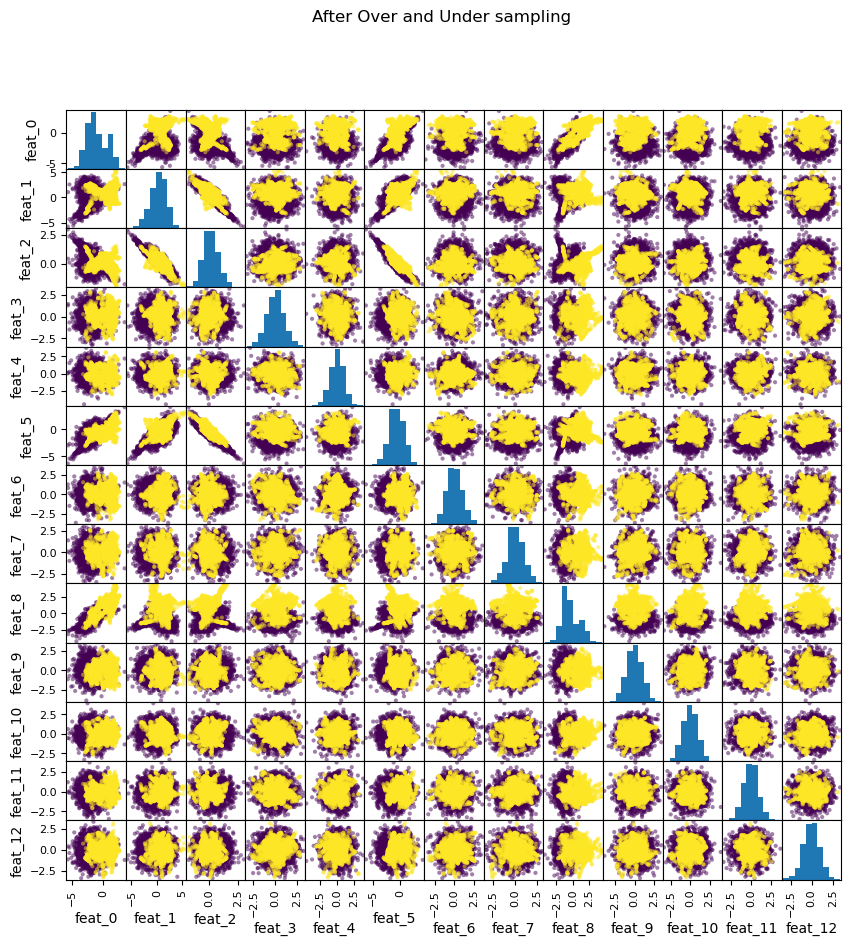

In [79]:
technique(X,y)

In [82]:
### TomekLinks
undersample = TomekLinks()

### SMOTE
oversample = SMOTE(sampling_strategy=0.5)

### SMOTEENN
sample = SMOTEENN(sampling_strategy=0.5)

### Evaluation
X_over, X_overtestX, y_over, y_overtesty = trainAndTest(X, y, oversample, True )
X_under, X_undertestX, y_under, y_undertesty = trainAndTest(X, y, undersample, True)
X_uo, X_uotestX, y_uo, y_uotesty = trainAndTest(X, y, sample, True)
for algorithm_name, algorithm in classification_algorithms.items():
    print(f"Algorithm: {algorithm_name}")
    print("Original Dataset")
    fit_to_logistic_regression(algorithm, X_train, X_test, y_train, y_test, data)
    print("--"*50)
    print("OVER Dataset")
    fit_to_logistic_regression(algorithm, X_over, X_overtestX, y_over, y_overtesty,data)
    print("--"*50)
    print("UNDER Dataset")
    fit_to_logistic_regression(algorithm, X_under, X_undertestX, y_under, y_undertesty,data)
    print("--"*50)
    print("UO Dataset")
    fit_to_logistic_regression(algorithm, X_uo, X_uotestX, y_uo, y_uotesty,data)
print(data)

Algorithm: Logistic-Regression
Original Dataset
 -->> TRAIN -->> Accuracy: 0.9725 |Precision: 0.9725 |Recall: 0.9725 |F1_score: 0.9725
 -->> TEST -->> Accuracy: 0.9690 |Precision: 0.9690 |Recall: 0.9690 |F1_score: 0.9690
----------------------------------------------------------------------------------------------------
OVER Dataset
 -->> TRAIN -->> Accuracy: 0.8904 |Precision: 0.8904 |Recall: 0.8904 |F1_score: 0.8904
 -->> TEST -->> Accuracy: 0.9425 |Precision: 0.9425 |Recall: 0.9425 |F1_score: 0.9425
----------------------------------------------------------------------------------------------------
UNDER Dataset


c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


 -->> TRAIN -->> Accuracy: 0.9720 |Precision: 0.9720 |Recall: 0.9720 |F1_score: 0.9720
 -->> TEST -->> Accuracy: 0.9675 |Precision: 0.9675 |Recall: 0.9675 |F1_score: 0.9675
----------------------------------------------------------------------------------------------------
UO Dataset
 -->> TRAIN -->> Accuracy: 0.8940 |Precision: 0.8940 |Recall: 0.8940 |F1_score: 0.8940
 -->> TEST -->> Accuracy: 0.9213 |Precision: 0.9213 |Recall: 0.9213 |F1_score: 0.9213
Algorithm: RandomForest
Original Dataset


c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


 -->> TRAIN -->> Accuracy: 1.0000 |Precision: 1.0000 |Recall: 1.0000 |F1_score: 1.0000
 -->> TEST -->> Accuracy: 0.9740 |Precision: 0.9740 |Recall: 0.9740 |F1_score: 0.9740
----------------------------------------------------------------------------------------------------
OVER Dataset
 -->> TRAIN -->> Accuracy: 1.0000 |Precision: 1.0000 |Recall: 1.0000 |F1_score: 1.0000
 -->> TEST -->> Accuracy: 0.9788 |Precision: 0.9788 |Recall: 0.9788 |F1_score: 0.9788
----------------------------------------------------------------------------------------------------
UNDER Dataset
 -->> TRAIN -->> Accuracy: 1.0000 |Precision: 1.0000 |Recall: 1.0000 |F1_score: 1.0000
 -->> TEST -->> Accuracy: 0.9750 |Precision: 0.9750 |Recall: 0.9750 |F1_score: 0.9750
----------------------------------------------------------------------------------------------------
UO Dataset
 -->> TRAIN -->> Accuracy: 1.0000 |Precision: 1.0000 |Recall: 1.0000 |F1_score: 1.0000
 -->> TEST -->> Accuracy: 0.9675 |Precision: 0.9675 |